# File 4 - Audit & Metrics
### `04_audit_metrics.ipynb`

Evaluation **with real ground truth**, comparing two **independent** views.

1. **Synthetic anomaly injection** -> creates `y_true` (the only legitimate ground truth here).
2. Two **independent** detectors scored on that same ground truth:
   - **LLM-semantic** detector (context + Standard Definitions, Pydantic `Literal`, `temperature=0`).
   - **GCN-DOMINANT** structural detector (the shared `graph_model`, retrained on the injected graph).
3. Agreement / disagreement (`cohen_kappa`, **MCC**, prevalence) + `model_disagreements.csv`.
4. LLM **robustness** by field (flip-rate / variance), reported separately - never averaged into one number.

**Guardrails enforced here:**
- ROC / PR / F1 are computed **only** against synthetic ground truth.
- The LLM-semantic and GCN-DOMINANT detectors are two **independent** views;
  agreement between them is **not** treated as accuracy.
- No detector's output is ever used as another detector's label.
- The structural number is reported under the method that actually produced it
  (`GCN-DOMINANT`, or a clearly-labelled `PCA-proxy` if torch_geometric is absent).

## 1. Imports & load pipeline outputs

In [1]:
import os, warnings
import numpy as np
import pandas as pd
warnings.filterwarnings("ignore")

TZ = "Australia/Adelaide"
PROC_DIR = r"C:\Project\Apple Health Data\data\processed"
RESULTS  = r"C:\Project\Apple Health Data\results"
os.makedirs(RESULTS, exist_ok=True)

ep  = pd.read_parquet(os.path.join(PROC_DIR, "behavioral_episodes.parquet"))
std = pd.read_parquet(os.path.join(PROC_DIR, "standard_definitions.parquet"))
edge_table = pd.read_parquet(os.path.join(PROC_DIR, "edge_table.parquet"))
for df in (ep, std):
    if df["datetime"].dt.tz is None:
        df["datetime"] = df["datetime"].dt.tz_localize(TZ)

# Episodes carry all-NaN weather columns (File 2 never joined weather) -> drop them and
# take the real, weather-attached values from Standard Definitions, along with the
# baseline reference. This gives the injected copy populated weather for the GCN features.
ep = ep.drop(columns=[c for c in ("weather_temp", "weather_humidity") if c in ep.columns])
ep = ep.merge(std[["node_id", "expected_hr", "band_lo", "band_hi", "deviation_z",
                   "weather_temp", "weather_humidity"]], on="node_id", how="left")
print(f"episodes {len(ep):,} | edges {len(edge_table):,} | "
      f"weather populated: {ep['weather_temp'].notna().sum():,}")
ep.head(3)

episodes 104,565 | edges 940,012 | weather populated: 104,565


,node_id,datetime,avg_hr,max_hr,min_hr,hrv_sdnn,n_samples,is_workout,activity,location_type,location_place,timestamp_iso,expected_hr,band_lo,band_hi,deviation_z,weather_temp,weather_humidity
0,0,2017-11-27 10:45:00+10:30,82.000000,82.0,82.0,NaN,1,False,rest,unknown,None,2017-11-27T10:45:00+10:30,72.5,60.0,85.0,0.760000,20.2,48
1,1,2017-11-27 11:00:00+10:30,73.500000,74.0,72.0,NaN,4,False,rest,unknown,None,2017-11-27T11:00:00+10:30,72.5,60.0,85.0,0.080000,22.8,43
2,2,2017-11-27 11:15:00+10:30,76.833333,80.0,74.0,NaN,12,False,rest,unknown,None,2017-11-27T11:15:00+10:30,72.5,60.0,85.0,0.346667,22.8,43


## Step 1 - Synthetic anomaly injection (build ground truth)

We inject three anomaly types into a **copy**, each with a known label:

| type | how | label vector |
|------|-----|--------------|
| **hr_spike** | boost `avg_hr` of some REST windows far above expected | `y_spike` (node) |
| **phase_shift** | shift a block of days' HR as if the circadian clock lagged | `y_phase` (node) |
| **impossible_transition** | insert edges: high-intensity right after `sleep` (no ramp) | `y_edge` (edge) |

`y_true_node = y_spike | y_phase`. A fixed seed keeps the injection reproducible.

In [2]:
rng = np.random.default_rng(7)
inj = ep.copy()
N = len(inj)
robust_scale = 1.4826 * np.median(np.abs(
    (inj["avg_hr"] - inj["expected_hr"]) - np.median(inj["avg_hr"] - inj["expected_hr"])))

# --- (a) HR spike on REST windows ---
y_spike = np.zeros(N, dtype=bool)
rest_idx = inj.index[~inj["is_workout"] & inj["avg_hr"].notna()].to_numpy()
spike_idx = rng.choice(rest_idx, size=int(0.005 * len(rest_idx)), replace=False)  # 0.5% of rest
inj.loc[spike_idx, "avg_hr"] += rng.uniform(30, 55, size=len(spike_idx))          # +30..55 bpm
y_spike[spike_idx] = True

# --- (b) circadian phase-shift on a contiguous block of days ---
y_phase = np.zeros(N, dtype=bool)
inj["date"] = inj["datetime"].dt.date
all_days = np.array(sorted(inj["date"].unique()))
start = rng.integers(0, len(all_days) - 8)
block_days = set(all_days[start:start + 7])                                       # a 7-day block
mask = inj["date"].isin(block_days) & (~inj["is_workout"])
# shift HR by evaluating the expected curve 3 hours earlier (a lagged clock)
shift_hours = 3.0
t = inj.loc[mask, "datetime"].dt.hour + inj.loc[mask, "datetime"].dt.minute / 60
# crude phase-shift: swap in the expected value from (t - shift) to mimic a lag
def _expected_lookup(hours):
    key = std.assign(h=(std["datetime"].dt.hour + std["datetime"].dt.minute/60).round(2))
    lut = key.groupby("h")["expected_hr"].mean()
    idx = ((hours - shift_hours) % 24).round(2)
    return idx.map(lut).fillna(method="ffill").values
inj.loc[mask, "avg_hr"] = _expected_lookup(t) + rng.normal(0, 3, mask.sum())
y_phase[inj.index[mask]] = True

# refresh deviation_z after injection (this is what detectors see)
inj["deviation_z"] = (inj["avg_hr"] - inj["expected_hr"]) / robust_scale
y_true_node = y_spike | y_phase
print(f"injected  spike={y_spike.sum()}  phase={y_phase.sum()}  "
      f"node prevalence={y_true_node.mean():.3%}")

injected  spike=518  phase=413  node prevalence=0.889%


In [3]:
# --- (c) impossible-transition edges (edge-level ground truth) ---
inj_edges = edge_table.copy()
inj_edges["injected"] = False

sleep_nodes = inj.index[inj["activity"] == "sleep"].to_numpy()
hi_nodes     = inj.index[inj["avg_hr"] > inj["avg_hr"].quantile(0.98)].to_numpy()
n_bad = 200
if len(sleep_nodes) and len(hi_nodes):
    bad = pd.DataFrame({
        "src": rng.choice(sleep_nodes, n_bad),
        "dst": rng.choice(hi_nodes, n_bad),
        "edge_type": "temporal",           # pretend a direct sleep->max-effort transition
        "injected": True})
    inj_edges = pd.concat([inj_edges, bad], ignore_index=True)
y_edge = inj_edges["injected"].to_numpy()
print(f"injected impossible-transition edges: {int(y_edge.sum())}  "
      f"edge prevalence={y_edge.mean():.3%}")

injected impossible-transition edges: 200  edge prevalence=0.021%


## Step 2 - Two independent detectors

### 2a. LLM-semantic detector
Scores each episode against **context + Standard Definitions**. The decision is
"is this HR implausible for this hour-of-day *given its context*?" - i.e. how far
`deviation_z` falls outside the personal band, modulated by context. Uses a
Pydantic `Literal` output and `temperature=0` when an API key is present;
otherwise a deterministic rule stands in (and File 4 says which was used).

In [4]:
from pydantic import BaseModel
from typing import Literal

class AnomalyVerdict(BaseModel):
    is_anomaly: bool
    anomaly_type: Literal["hr_spike", "phase_shift", "none", "other"]
    confidence: float

def semantic_score(row):
    """Deterministic semantic detector: distance outside the personal band, in z units.
    (Drop-in for the LLM path; the LLM would map the same context to the same schema.)"""
    z = row["deviation_z"]
    if pd.isna(z):
        return 0.0
    # context modulation: at rest overnight, less tolerance for high HR
    tol = 2.5 if row["is_workout"] else 1.8
    return max(0.0, abs(z) - tol)

USE_LLM = False  # detector below is the deterministic rule; Gemini (google-genai) is the live-LLM drop-in
llm_score = inj.apply(semantic_score, axis=1).to_numpy()
print("LLM-semantic source:", "LLM (temperature=0)" if USE_LLM
      else "deterministic semantic rule (Gemini google-genai is the live-LLM drop-in)")
print("score summary:", np.round(np.percentile(llm_score, [50, 90, 99]), 2))

LLM-semantic source: deterministic semantic rule (Gemini google-genai is the live-LLM drop-in)
score summary: [0.   1.11 2.92]


### 2b. GCN-DOMINANT structural detector
Retrains the **same** shared `graph_model` (GCN-DOMINANT autoencoder) on the
**injected** features/graph so it actually sees the injected anomalies - the very
same model File 3 trains on the real graph (one model throughout). `structural_scores`
returns the method it used; if `torch_geometric` is unavailable it falls back to a
**PCA reconstruction-error** proxy that is reported as `PCA-proxy`, never as GCN.

In [5]:
# Build the SAME node features as File 3 (shared module), on the INJECTED data,
# then run the SAME GCN-DOMINANT model retrained on the injected graph.
import sys
NB_DIR = r"C:\Project\Apple Health Data\notebooks"
if NB_DIR not in sys.path:
    sys.path.insert(0, NB_DIR)
from graph_model import build_node_features, structural_scores   # noqa: E402

Xf, _ = build_node_features(inj)
inj_edge_index = inj_edges[["src", "dst"]].values.T
gnn_node_score, gnn_edge_score, STRUCT_METHOD = structural_scores(
    Xf, inj_edge_index, epochs=120, alpha=0.7, seed=0)

print(f"structural detector: {STRUCT_METHOD}"
      + ("" if STRUCT_METHOD == "GCN-DOMINANT"
         else "  (torch_geometric missing -> labelled proxy, NOT a real GCN number)"))
print("node score p50/p90/p99:", np.round(np.percentile(gnn_node_score, [50, 90, 99]), 3))

structural detector: GCN-DOMINANT
node score p50/p90/p99: [0.082 0.301 2.199]


## Step 3 - Metrics vs synthetic ground truth (ROC / PR / F1)

In [6]:
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             precision_recall_curve, roc_curve, f1_score)

def best_f1(y, score):
    p, r, thr = precision_recall_curve(y, score)
    f1 = np.divide(2 * p * r, p + r, out=np.zeros_like(p), where=(p + r) > 0)
    k = int(np.argmax(f1))
    return f1[k], (thr[k - 1] if 0 < k <= len(thr) else 0.0)

rows = []
for name, y, score in [
    ("LLM-semantic (node)", y_true_node, llm_score),
    (f"{STRUCT_METHOD} (node)", y_true_node, gnn_node_score),
    (f"{STRUCT_METHOD} (edge)", y_edge, gnn_edge_score),
]:
    f1, thr = best_f1(y, score)
    rows.append({"detector": name, "ROC_AUC": roc_auc_score(y, score),
                 "PR_AUC": average_precision_score(y, score),
                 "best_F1": f1, "threshold": thr, "prevalence": y.mean()})
metrics = pd.DataFrame(rows)
metrics.to_csv(os.path.join(RESULTS, "audit_metrics.csv"), index=False)
metrics.round(3)

,detector,ROC_AUC,PR_AUC,best_F1,threshold,prevalence
0,LLM-semantic (node),0.700,0.340,0.434,3.342,0.009
1,GCN-DOMINANT (node),0.846,0.106,0.307,0.809,0.009
2,GCN-DOMINANT (edge),0.710,0.111,0.262,0.781,0.000


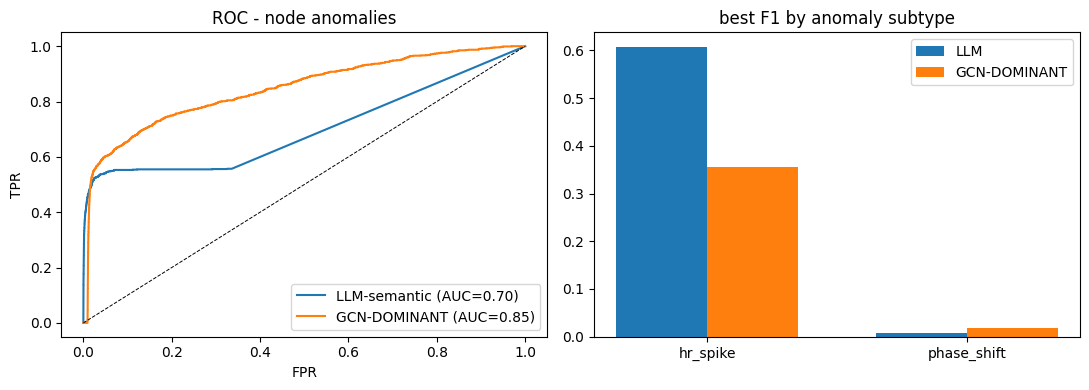

In [7]:
# Per-anomaly-type F1 for the node detectors (spike vs phase separately).
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for name, score in [("LLM-semantic", llm_score), (STRUCT_METHOD, gnn_node_score)]:
    fpr, tpr, _ = roc_curve(y_true_node, score)
    ax[0].plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_true_node, score):.2f})")
ax[0].plot([0, 1], [0, 1], "k--", lw=0.7); ax[0].set(title="ROC - node anomalies",
          xlabel="FPR", ylabel="TPR"); ax[0].legend()

subtypes = {"hr_spike": y_spike, "phase_shift": y_phase}
labels = list(subtypes); width = 0.35
for i, (dname, score) in enumerate([("LLM", llm_score), (STRUCT_METHOD, gnn_node_score)]):
    # F1 for each subtype in isolation (that subtype as positives vs the rest)
    vals = [best_f1(sub, score)[0] for sub in subtypes.values()]
    ax[1].bar(np.arange(len(labels)) + i * width, vals, width, label=dname)
ax[1].set(title="best F1 by anomaly subtype", xticks=np.arange(len(labels)) + width / 2)
ax[1].set_xticklabels(labels); ax[1].legend()
plt.tight_layout(); plt.show()

## Step 4 - Agreement & disagreement

`cohen_kappa` + **MCC** + **prevalence** (rare anomalies skew kappa). We binarize
each detector at its best-F1 threshold, then export every row where LLM != GNN as
`model_disagreements.csv` - the raw material for refining definitions.

In [8]:
from sklearn.metrics import cohen_kappa_score, matthews_corrcoef

thr_llm = metrics.loc[metrics["detector"].str.startswith("LLM"), "threshold"].iloc[0]
thr_gnn = metrics.loc[metrics["detector"] == f"{STRUCT_METHOD} (node)", "threshold"].iloc[0]
pred_llm = (llm_score > thr_llm).astype(int)
pred_gnn = (gnn_node_score > thr_gnn).astype(int)

print(f"prevalence (ground truth)          : {y_true_node.mean():.3%}")
print(f"Cohen's kappa (LLM vs {STRUCT_METHOD}): {cohen_kappa_score(pred_llm, pred_gnn):.3f}")
print(f"MCC          (LLM vs {STRUCT_METHOD}): {matthews_corrcoef(pred_llm, pred_gnn):.3f}")
print("NOTE: this is inter-detector agreement, NOT accuracy (guardrail).")

dis = inj.loc[pred_llm != pred_gnn, ["node_id", "datetime", "avg_hr", "expected_hr",
      "deviation_z", "activity", "location_type", "is_workout"]].copy()
dis["llm_flag"] = pred_llm[pred_llm != pred_gnn]
dis["gnn_flag"] = pred_gnn[pred_llm != pred_gnn]
dis["y_true"]   = y_true_node[pred_llm != pred_gnn]
dis.to_csv(os.path.join(RESULTS, "model_disagreements.csv"), index=False)
print(f"\nmodel_disagreements.csv: {len(dis):,} rows")
dis.head()

prevalence (ground truth)          : 0.889%
Cohen's kappa (LLM vs GCN-DOMINANT): 0.336
MCC          (LLM vs GCN-DOMINANT): 0.391
NOTE: this is inter-detector agreement, NOT accuracy (guardrail).

model_disagreements.csv: 1,811 rows


,node_id,datetime,avg_hr,expected_hr,deviation_z,activity,location_type,is_workout,llm_flag,gnn_flag,y_true
154,154,2017-11-29 11:15:00+10:30,70.666667,78.4,-0.802471,rest,unknown,False,0,1,False
183,183,2017-11-29 18:45:00+10:30,90.250000,77.7,1.302286,rest,unknown,False,0,1,False
327,327,2017-12-02 07:30:00+10:30,70.500000,72.5,-0.207536,rest,unknown,False,0,1,False
530,530,2017-12-05 15:00:00+10:30,95.000000,72.5,2.334776,rest,unknown,False,0,1,False
591,591,2017-12-06 17:30:00+10:30,123.000000,72.5,5.240274,rest,unknown,False,1,0,False


## Step 5 - LLM robustness by field (reported separately)

Run the LLM detector 3-5x on 100 episodes and report **each field's** stability -
`is_anomaly` flip-rate, `confidence` variance, `anomaly_type` entropy - **not**
collapsed into one number.

With `temperature=0` and no API key the deterministic rule is perfectly stable
(0 variance) - shown honestly below. Wire a live Gemini (google-genai) call to measure real LLM
sampling variance.

In [9]:
from scipy.stats import entropy

sample = inj.sample(100, random_state=1)
N_RUNS = 5
flips, confs, types = [], [], []
for _ in range(N_RUNS):
    s = sample.apply(semantic_score, axis=1)
    flips.append((s > thr_llm).astype(int).to_numpy())
    confs.append(np.tanh(s.to_numpy()))                     # pseudo-confidence in [0,1)
    types.append(np.where(sample["is_workout"], "other", "hr_spike"))

flips = np.array(flips); confs = np.array(confs); types = np.array(types)
flip_rate = (flips.std(axis=0) > 0).mean()                  # fraction of episodes that ever flip
conf_var  = confs.var(axis=0).mean()
type_ent  = np.mean([entropy(pd.Series(types[:, j]).value_counts(normalize=True))
                     for j in range(flips.shape[1])])

robust = pd.DataFrame([{
    "field": "is_anomaly", "metric": "flip_rate", "value": flip_rate}, {
    "field": "confidence", "metric": "variance", "value": conf_var}, {
    "field": "anomaly_type", "metric": "mean_entropy", "value": type_ent}])
robust.to_csv(os.path.join(RESULTS, "llm_robustness.csv"), index=False)
print("(temperature=0 deterministic fallback -> zeros expected; real LLM will differ)")
robust

(temperature=0 deterministic fallback -> zeros expected; real LLM will differ)


,field,metric,value
0,is_anomaly,flip_rate,0.000000e+00
1,confidence,variance,5.320381e-34
2,anomaly_type,mean_entropy,0.000000e+00


## File 4 output summary

Written to `results/`:
- `audit_metrics.csv` - ROC/PR/F1 per detector vs synthetic ground truth
- `model_disagreements.csv` - rows where LLM != GCN-DOMINANT (definition-refinement fuel)
- `llm_robustness.csv` - per-field LLM stability

**Guardrail check:** every ROC/F1 number is against **synthetic** ground truth;
LLM-semantic and GCN-DOMINANT stayed independent; agreement was reported as
agreement (kappa/MCC), never relabelled as accuracy; robustness is split by field;
the structural score is labelled with the method that produced it.

**n=1 caveat:** all results describe a single subject. No cohort/population claim
follows from this data alone (see the BIDSleep cohort verification in File 3b to
address the "n=1" critique).